# Seq2Seq with Bahdanau Attention — from scratch in PyTorch

This notebook builds a **sequence-to-sequence model with Bahdanau (additive) attention** entirely from scratch — no `nn.MultiheadAttention`, no high-level seq2seq libraries. Every matrix multiply in the attention mechanism is written out explicitly so you can see exactly what's happening.

**Toy task:** sequence reversal. Given a random string of letters, e.g. `g j a a b i e`, the model must output it reversed: `e i b a a j g`.

This task is deliberately simple — the point isn't the task itself, it's that reversal produces a **clean, visualizable alignment** between input and output positions (an anti-diagonal pattern), which makes it easy to *see* attention working. The same code works unchanged on real translation data; only the dataset class would change.

### What you'll learn
1. Why vanilla seq2seq (encoder → single fixed vector → decoder) struggles with long sequences
2. How Bahdanau attention solves this by letting the decoder look back at *all* encoder states, weighted dynamically
3. A full from-scratch implementation: Encoder, Attention module, Decoder, training loop
4. How to visualize attention weights to verify the model learned a sensible alignment

## 1. The core idea (concept walkthrough)

### The problem with vanilla seq2seq
A classic encoder-decoder (Sutskever et al., 2014) compresses an *entire* input sequence into a single fixed-size context vector (typically the encoder's final hidden state). The decoder then has to generate the entire output using only that one vector.

This is a severe bottleneck: a 50-word sentence and a 5-word sentence get squeezed into the same size vector. Performance degrades sharply as sequences get longer, because early-sequence information gets diluted/overwritten by the time the encoder reaches the end.

### Bahdanau's fix: attention
Bahdanau, Cho & Bengio (2014), *"Neural Machine Translation by Jointly Learning to Align and Translate"*, proposed instead keeping **every encoder hidden state** (one per input token) around, and letting the decoder, at *each* output step, compute a fresh weighted combination of all of them — a **context vector that changes at every decoding step**.

Concretely, at decoder step $t$, with decoder hidden state $s_{t-1}$ and encoder hidden states $h_1, \dots, h_T$:

$$e_{t,i} = v^\top \tanh(W_s s_{t-1} + W_h h_i) \qquad \text{(alignment score for each encoder position } i\text{)}$$
$$\alpha_{t,i} = \frac{\exp(e_{t,i})}{\sum_{j=1}^{T}\exp(e_{t,j})} \qquad \text{(softmax} \to \text{attention weights, sum to 1)}$$
$$c_t = \sum_{i=1}^{T} \alpha_{t,i}\, h_i \qquad \text{(context vector = weighted sum of encoder states)}$$

The decoder then uses $c_t$ (concatenated with its own input embedding) to update its hidden state and predict the next token.

**Intuition:** instead of forcing one vector to represent the whole sentence, the decoder gets to *ask a question* at every step ("given what I've generated so far, which input words matter right now?") and the answer is a soft, learned, differentiable lookup over the source sequence. This is why it's sometimes described as a **soft, differentiable dictionary lookup** — $W_s s_{t-1}$ is like a query, $W_h h_i$ are like keys, and $\alpha_{t,i}$ are the weights used to retrieve a blend of the values $h_i$.

This is the direct conceptual ancestor of the Query/Key/Value attention used in Transformers — Bahdanau attention is **additive attention** (scores computed via a small feedforward net + tanh), whereas Transformers use **dot-product attention** (scores computed via $QK^\top$). The softmax-weighted-sum idea is identical.

### Why visualize attention on a reversal task?
Because the correct alignment is known in advance: output position $t$ should attend almost entirely to input position $T - t$. When we plot the attention weight matrix $\alpha_{t,i}$ as a heatmap (decoder steps on one axis, encoder positions on the other), a well-trained model should show a clean **anti-diagonal** line. This gives us a simple, visual sanity check that attention is doing something meaningful and not just learning a shortcut.

## 2. Setup

In [1]:
import random
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## 3. Toy dataset: sequence reversal

- Vocabulary: lowercase letters `a`–`j` (10 symbols) plus 3 special tokens: `<pad>`, `<sos>` (start of sequence), `<eos>` (end of sequence).
- Each example is a random-length sequence (5–10 tokens) of random letters.
- The *target* is simply the input reversed.
- We append `<eos>` to both source and target so the model learns when a sequence ends (essential for variable-length generation), and prepend `<sos>` to the target to seed the decoder's first input.

This is a **toy stand-in for translation/copy tasks**: swap `make_example()` for a real (source, target) sentence pair loader and everything else — encoder, attention, decoder, training loop — works unchanged.

In [2]:
PAD, SOS, EOS = 0, 1, 2
SPECIAL_TOKENS = {"<pad>": PAD, "<sos>": SOS, "<eos>": EOS}
VOCAB = list("abcdefghij")  # 10 symbols
token2idx = {**SPECIAL_TOKENS, **{tok: i + 3 for i, tok in enumerate(VOCAB)}}
idx2token = {i: t for t, i in token2idx.items()}
VOCAB_SIZE = len(token2idx)

print("Vocab size:", VOCAB_SIZE)
print("Token mapping:", token2idx)

Vocab size: 13
Token mapping: {'<pad>': 0, '<sos>': 1, '<eos>': 2, 'a': 3, 'b': 4, 'c': 5, 'd': 6, 'e': 7, 'f': 8, 'g': 9, 'h': 10, 'i': 11, 'j': 12}


In [3]:
MIN_LEN, MAX_LEN = 5, 10

def make_example():
    """Generate one (source, target) pair: target is source reversed."""
    length = random.randint(MIN_LEN, MAX_LEN)
    seq = [random.choice(VOCAB) for _ in range(length)]
    src = seq
    tgt = list(reversed(seq))
    return src, tgt

def encode(tokens, add_eos=True):
    ids = [token2idx[t] for t in tokens]
    if add_eos:
        ids = ids + [EOS]
    return ids

# sanity check
s, t = make_example()
print("source:", s)
print("target:", t)

source: ['b', 'a', 'e', 'd', 'd', 'c', 'b', 'i', 'b', 'j']
target: ['j', 'b', 'i', 'b', 'c', 'd', 'd', 'e', 'a', 'b']


In [4]:
class ReverseDataset(torch.utils.data.Dataset):
    """Generates `n_examples` random (source, target) reversal pairs."""
    def __init__(self, n_examples):
        self.data = [make_example() for _ in range(n_examples)]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        src, tgt = self.data[idx]
        src_ids = encode(src, add_eos=True)          # [.., <eos>]
        tgt_ids = [SOS] + encode(tgt, add_eos=True)   # [<sos>, .., <eos>]
        return torch.tensor(src_ids), torch.tensor(tgt_ids)


def collate_batch(batch):
    """Pads a batch of variable-length (src, tgt) pairs and records true lengths
    (lengths are needed for pack_padded_sequence and for building the attention mask)."""
    srcs, tgts = zip(*batch)
    src_lens = torch.tensor([len(s) for s in srcs])
    tgt_lens = torch.tensor([len(t) for t in tgts])
    src_pad = nn.utils.rnn.pad_sequence(srcs, batch_first=True, padding_value=PAD)
    tgt_pad = nn.utils.rnn.pad_sequence(tgts, batch_first=True, padding_value=PAD)
    return src_pad, src_lens, tgt_pad, tgt_lens


train_ds = ReverseDataset(4000)
val_ds   = ReverseDataset(400)

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=64, shuffle=True,  collate_fn=collate_batch)
val_loader   = torch.utils.data.DataLoader(val_ds,   batch_size=64, shuffle=False, collate_fn=collate_batch)

# peek at one batch
src, src_lens, tgt, tgt_lens = next(iter(train_loader))
print("src batch shape:", src.shape, "| tgt batch shape:", tgt.shape)
print("src_lens[:5]:", src_lens[:5].tolist())

src batch shape: torch.Size([64, 11]) | tgt batch shape: torch.Size([64, 12])
src_lens[:5]: [9, 8, 7, 9, 10]


## 4. The Encoder

The encoder is a **bidirectional GRU**. It reads the source sequence and produces:
- `encoder_outputs`: one hidden vector *per input position* (concatenation of forward + backward GRU states). These are the things attention will look at.
- `decoder_init_hidden`: a single vector used to initialize the decoder's hidden state, obtained by concatenating the final forward/backward hidden states and projecting through a linear + tanh layer.

We use `pack_padded_sequence`/`pad_packed_sequence` so the GRU doesn't waste computation (or get confused) processing `<pad>` tokens in shorter sequences within a batch.

**Why bidirectional?** Each encoder output then has both left-context and right-context information, which gives attention richer representations to choose from — useful even on reversal, and essential for real translation where word order can differ a lot between languages.

In [5]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_layers=1, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD)
        self.dropout = nn.Dropout(dropout)
        self.rnn = nn.GRU(
            emb_dim, hidden_dim, num_layers=num_layers,
            batch_first=True, bidirectional=True,
        )
        # project [fwd_final ; bwd_final] (2*hidden_dim) down to hidden_dim
        # to seed the (unidirectional) decoder's initial hidden state
        self.fc_hidden = nn.Linear(hidden_dim * 2, hidden_dim)

    def forward(self, src, src_lens):
        # src: (batch, src_len)
        embedded = self.dropout(self.embedding(src))                      # (batch, src_len, emb_dim)

        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, src_lens.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_outputs, hidden = self.rnn(packed)
        # outputs is trimmed to the longest *true* length in this batch
        outputs, _ = nn.utils.rnn.pad_packed_sequence(packed_outputs, batch_first=True)
        # outputs: (batch, src_len_in_batch, hidden_dim * 2)  <- one vector per source token

        # hidden: (num_layers * 2, batch, hidden_dim) -- last layer's fwd/bwd final states
        hidden_fwd = hidden[-2]   # forward direction, last layer
        hidden_bwd = hidden[-1]   # backward direction, last layer
        hidden_cat = torch.cat([hidden_fwd, hidden_bwd], dim=1)            # (batch, hidden_dim*2)
        decoder_init_hidden = torch.tanh(self.fc_hidden(hidden_cat))       # (batch, hidden_dim)

        return outputs, decoder_init_hidden

## 5. Bahdanau Attention — the heart of this notebook

This module implements exactly the three equations from §1:

```
score(s, h_i)   = v^T tanh(W_dec @ s + W_enc @ h_i)     # additive / 'concat' attention
alpha           = softmax(score)   over encoder positions i, with padding masked out
context         = sum_i alpha_i * h_i
```

A few implementation details worth calling out:
- `W_enc` is applied to **all** encoder outputs at once (it doesn't depend on the decoder step), so we can precompute `enc_proj` once per batch in principle — here we recompute it per step for simplicity, but for a serious implementation you'd want to hoist it out of the decoding loop for speed.
- The **mask** sets scores for padding positions to $-\infty$ before the softmax, so padded positions get *exactly* zero attention weight, regardless of what the (meaningless) padding embeddings happen to produce.
- `v` is a learned linear layer mapping the `attn_dim`-sized hidden vector down to a single scalar score per position — this is what makes it additive attention rather than a dot product.

In [6]:
class BahdanauAttention(nn.Module):
    def __init__(self, enc_hidden_dim, dec_hidden_dim, attn_dim):
        super().__init__()
        # NOTE: enc_hidden_dim here is the *unidirectional* hidden size; encoder
        # outputs are bidirectional so their feature dim is enc_hidden_dim * 2.
        self.W_enc = nn.Linear(enc_hidden_dim * 2, attn_dim, bias=False)
        self.W_dec = nn.Linear(dec_hidden_dim, attn_dim, bias=False)
        self.v = nn.Linear(attn_dim, 1, bias=False)

    def forward(self, decoder_hidden, encoder_outputs, mask):
        """
        decoder_hidden:   (batch, dec_hidden_dim)            -- s_{t-1}
        encoder_outputs:  (batch, src_len, enc_hidden_dim*2) -- h_1 .. h_T
        mask:             (batch, src_len)  1 = real token, 0 = padding
        returns:
          context:        (batch, enc_hidden_dim*2)
          attn_weights:   (batch, src_len)   -- alpha_{t,i}, sums to 1 over dim=1
        """
        # broadcast decoder hidden across all source positions
        dec_proj = self.W_dec(decoder_hidden).unsqueeze(1)         # (batch, 1, attn_dim)
        enc_proj = self.W_enc(encoder_outputs)                     # (batch, src_len, attn_dim)

        # additive attention score: v^T tanh(W_dec s + W_enc h_i)
        scores = self.v(torch.tanh(dec_proj + enc_proj)).squeeze(2)  # (batch, src_len)

        # mask out padding positions before softmax so they get ~0 weight
        scores = scores.masked_fill(mask == 0, float("-inf"))

        attn_weights = F.softmax(scores, dim=1)                    # (batch, src_len)

        # context = weighted sum of encoder outputs
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs).squeeze(1)  # (batch, enc_hidden_dim*2)

        return context, attn_weights

## 6. The Decoder

At every output step the decoder:
1. Embeds the previous output token (ground truth during teacher-forcing, or its own previous prediction otherwise).
2. Calls `BahdanauAttention` using its *current* hidden state and the (fixed, precomputed) encoder outputs to get a fresh `context` vector.
3. Feeds `[embedding ; context]` into a GRU cell to get the new hidden state.
4. Predicts the next token from `[gru_output ; context ; embedding]` — concatenating all three (a common trick from the original paper's "deep output" layer) gives the output layer direct access to the attention context and the current input, not just the GRU's hidden state.

We implement this as `forward_step`, processing **one decoder timestep at a time**, because attention recomputes the context at every step — unlike a vanilla decoder, the input to the GRU at step $t$ depends on attention weights that themselves depend on the hidden state at $t-1$, so we can't unroll it as a single multi-step RNN call.

In [7]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, enc_hidden_dim, dec_hidden_dim, attn_dim, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD)
        self.dropout = nn.Dropout(dropout)
        self.attention = BahdanauAttention(enc_hidden_dim, dec_hidden_dim, attn_dim)
        # GRU input = [token embedding ; attention context]
        self.rnn = nn.GRU(emb_dim + enc_hidden_dim * 2, dec_hidden_dim, batch_first=True)
        # output layer sees GRU output, context, AND the input embedding ("deep output")
        self.fc_out = nn.Linear(emb_dim + enc_hidden_dim * 2 + dec_hidden_dim, vocab_size)

    def forward_step(self, input_token, hidden, encoder_outputs, mask):
        """
        input_token:      (batch,)              -- token ids for this single step
        hidden:            (batch, dec_hidden_dim) -- previous decoder hidden state s_{t-1}
        encoder_outputs:   (batch, src_len, enc_hidden_dim*2)
        mask:              (batch, src_len)
        """
        embedded = self.dropout(self.embedding(input_token)).unsqueeze(1)   # (batch, 1, emb_dim)

        context, attn_weights = self.attention(hidden, encoder_outputs, mask)  # (batch, enc_hidden_dim*2), (batch, src_len)

        rnn_input = torch.cat([embedded, context.unsqueeze(1)], dim=2)      # (batch, 1, emb_dim + enc_hidden_dim*2)
        output, hidden_new = self.rnn(rnn_input, hidden.unsqueeze(0))
        hidden_new = hidden_new.squeeze(0)    # (batch, dec_hidden_dim)
        output = output.squeeze(1)            # (batch, dec_hidden_dim)

        combined = torch.cat([output, context, embedded.squeeze(1)], dim=1)
        logits = self.fc_out(combined)        # (batch, vocab_size)

        return logits, hidden_new, attn_weights


def make_src_mask(src_lens, max_len):
    """Build a (batch, max_len) boolean-as-float mask from sequence lengths.
    IMPORTANT: built from lengths against `max_len = encoder_outputs.size(1)`, NOT
    from raw padded `src` width. `pad_packed_sequence` trims encoder_outputs to the
    longest *true* length within whatever batch/sub-batch is passed in, which can be
    narrower than src's padded width (e.g. when slicing a few rows out of a wider-
    padded tensor at inference time) -- masking against the wrong width causes a
    shape mismatch."""
    batch_size = src_lens.size(0)
    arange = torch.arange(max_len, device=src_lens.device).unsqueeze(0).expand(batch_size, -1)
    mask = (arange < src_lens.unsqueeze(1)).to(torch.float32)
    return mask

## 7. Putting it together: the Seq2Seq wrapper

`forward()` runs the full training-time loop: encode once, then decode step-by-step, using **teacher forcing** — at each step, with probability `teacher_forcing_ratio` we feed the *true* previous target token into the decoder instead of its own (possibly wrong) prediction. This stabilizes training early on, when the decoder's own predictions would mostly be garbage.

`greedy_decode()` is the inference-time version: no teacher forcing, no ground truth available — the decoder must feed its own previous prediction back in at every step, starting from `<sos>`. We also return the full attention weight matrix so we can visualize it afterward.

In [8]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, src_lens, tgt, teacher_forcing_ratio=0.5):
        batch_size, tgt_len = tgt.shape
        vocab_size = self.decoder.fc_out.out_features
        outputs = torch.zeros(batch_size, tgt_len, vocab_size, device=self.device)

        encoder_outputs, hidden = self.encoder(src, src_lens)
        mask = make_src_mask(src_lens, encoder_outputs.size(1))

        input_token = tgt[:, 0]   # <sos> for every example
        for t in range(1, tgt_len):
            logits, hidden, _ = self.decoder.forward_step(input_token, hidden, encoder_outputs, mask)
            outputs[:, t] = logits
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = logits.argmax(1)
            input_token = tgt[:, t] if teacher_force else top1
        return outputs

    @torch.no_grad()
    def greedy_decode(self, src, src_lens, max_len=15):
        self.eval()
        encoder_outputs, hidden = self.encoder(src, src_lens)
        mask = make_src_mask(src_lens, encoder_outputs.size(1))

        batch_size = src.size(0)
        input_token = torch.full((batch_size,), SOS, dtype=torch.long, device=self.device)

        all_tokens, all_attn = [], []
        for _ in range(max_len):
            logits, hidden, attn_weights = self.decoder.forward_step(input_token, hidden, encoder_outputs, mask)
            top1 = logits.argmax(1)
            all_tokens.append(top1)
            all_attn.append(attn_weights)
            input_token = top1   # feed own prediction back in

        tokens = torch.stack(all_tokens, dim=1)   # (batch, max_len)
        attns  = torch.stack(all_attn, dim=1)     # (batch, max_len, src_len)
        return tokens, attns

## 8. Build the model

Small hyperparameters are enough for this toy task — feel free to scale them up for harder problems.

In [9]:
EMB_DIM    = 32
ENC_HIDDEN = 64
DEC_HIDDEN = 64
ATTN_DIM   = 32

encoder = Encoder(VOCAB_SIZE, EMB_DIM, ENC_HIDDEN).to(device)
decoder = Decoder(VOCAB_SIZE, EMB_DIM, ENC_HIDDEN, DEC_HIDDEN, ATTN_DIM).to(device)
model = Seq2Seq(encoder, decoder, device).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Total trainable parameters: {n_params:,}")

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=PAD)   # ignore padding positions in the loss

Total trainable parameters: 99,213


## 9. Training loop

Standard supervised training: compute logits for every output position, compare against the target with cross-entropy (ignoring `<pad>` positions), backprop, clip gradients (RNNs are prone to exploding gradients), step.

We linearly decay the teacher-forcing ratio across epochs — leaning on ground truth early, increasingly relying on the model's own predictions later, which better matches what it will face at inference time.

In [10]:
def train_epoch(model, loader, optimizer, criterion, tf_ratio=0.5):
    model.train()
    total_loss = 0
    for src, src_lens, tgt, tgt_lens in loader:
        src, tgt = src.to(device), tgt.to(device)
        optimizer.zero_grad()
        outputs = model(src, src_lens, tgt, teacher_forcing_ratio=tf_ratio)
        # outputs[:, 1:] skips the <sos> slot (never predicted); same for tgt
        loss = criterion(outputs[:, 1:].reshape(-1, outputs.size(-1)), tgt[:, 1:].reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    for src, src_lens, tgt, tgt_lens in loader:
        src, tgt = src.to(device), tgt.to(device)
        outputs = model(src, src_lens, tgt, teacher_forcing_ratio=0.0)  # no teacher forcing at eval
        loss = criterion(outputs[:, 1:].reshape(-1, outputs.size(-1)), tgt[:, 1:].reshape(-1))
        total_loss += loss.item()
    return total_loss / len(loader)

In [11]:
N_EPOCHS = 10
history = {"train_loss": [], "val_loss": []}

for epoch in range(N_EPOCHS):
    tf_ratio = max(0.5 - epoch * 0.05, 0.1)   # decay teacher forcing from 0.5 -> 0.1
    train_loss = train_epoch(model, train_loader, optimizer, criterion, tf_ratio=tf_ratio)
    val_loss = evaluate(model, val_loader, criterion)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    print(f"Epoch {epoch+1:2d}/{N_EPOCHS} | tf_ratio={tf_ratio:.2f} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

Epoch  1/10 | tf_ratio=0.50 | train_loss=2.1267 | val_loss=1.7098


Epoch  2/10 | tf_ratio=0.45 | train_loss=1.1969 | val_loss=0.5347


Epoch  3/10 | tf_ratio=0.40 | train_loss=0.3401 | val_loss=0.0925


Epoch  4/10 | tf_ratio=0.35 | train_loss=0.1160 | val_loss=0.0432


Epoch  5/10 | tf_ratio=0.30 | train_loss=0.0715 | val_loss=0.0177


Epoch  6/10 | tf_ratio=0.25 | train_loss=0.0241 | val_loss=0.0147


Epoch  7/10 | tf_ratio=0.20 | train_loss=0.0227 | val_loss=0.0163


Epoch  8/10 | tf_ratio=0.15 | train_loss=0.0203 | val_loss=0.0080


Epoch  9/10 | tf_ratio=0.10 | train_loss=0.0265 | val_loss=0.0077


Epoch 10/10 | tf_ratio=0.10 | train_loss=0.0112 | val_loss=0.0017


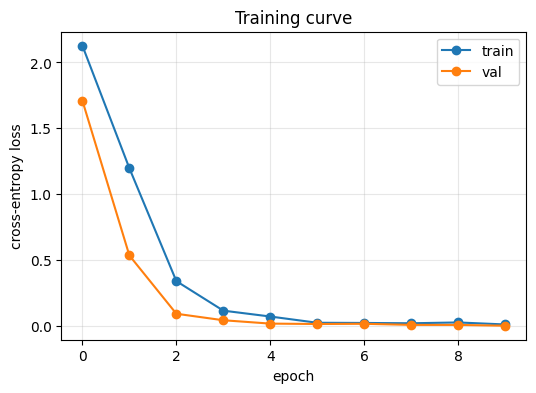

In [12]:
plt.figure(figsize=(6,4))
plt.plot(history["train_loss"], label="train", marker="o")
plt.plot(history["val_loss"], label="val", marker="o")
plt.xlabel("epoch")
plt.ylabel("cross-entropy loss")
plt.title("Training curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 10. Qualitative evaluation: does it actually reverse sequences?

In [13]:
def tokens_to_str(ids):
    """Convert a list/tensor of token ids back into a readable string, stopping at <eos>."""
    out = []
    for i in ids:
        i = int(i)
        if i == EOS:
            break
        if i in (PAD, SOS):
            continue
        out.append(idx2token[i])
    return "".join(out)


src, src_lens, tgt, tgt_lens = next(iter(val_loader))
src, tgt = src.to(device), tgt.to(device)

pred_tokens, attn = model.greedy_decode(src, src_lens, max_len=tgt.size(1))

n_correct = 0
n_show = 8
for i in range(src.size(0)):
    s = tokens_to_str(src[i].tolist())
    g = tokens_to_str(tgt[i].tolist())
    p = tokens_to_str(pred_tokens[i].tolist())
    if g == p:
        n_correct += 1
    if i < n_show:
        mark = "OK" if g == p else "XX"
        print(f"[{mark}] src={s:<12} target={g:<12} pred={p:<12}")

print(f"\nExact-match accuracy on this validation batch: {n_correct}/{src.size(0)} = {100*n_correct/src.size(0):.1f}%")

[OK] src=jddfji       target=ijfddj       pred=ijfddj      
[OK] src=eheccjidfj   target=jfdijccehe   pred=jfdijccehe  
[OK] src=ghhbfdja     target=ajdfbhhg     pred=ajdfbhhg    
[OK] src=cgcehd       target=dhecgc       pred=dhecgc      
[OK] src=faadcjja     target=ajjcdaaf     pred=ajjcdaaf    
[OK] src=aagehgbee    target=eebghegaa    pred=eebghegaa   
[OK] src=hihdff       target=ffdhih       pred=ffdhih      
[OK] src=aecdbgj      target=jgbdcea      pred=jgbdcea     

Exact-match accuracy on this validation batch: 64/64 = 100.0%


## 11. Visualizing attention — the payoff

For a reversal task, output step $t$ should attend almost entirely to input position $T - 1 - t$ (0-indexed). If our Bahdanau attention has learned correctly, the heatmap below should show a clear **anti-diagonal band** of high attention weight.

Rows = decoder output steps, columns = source positions. Brighter = higher attention weight $\alpha_{t,i}$.

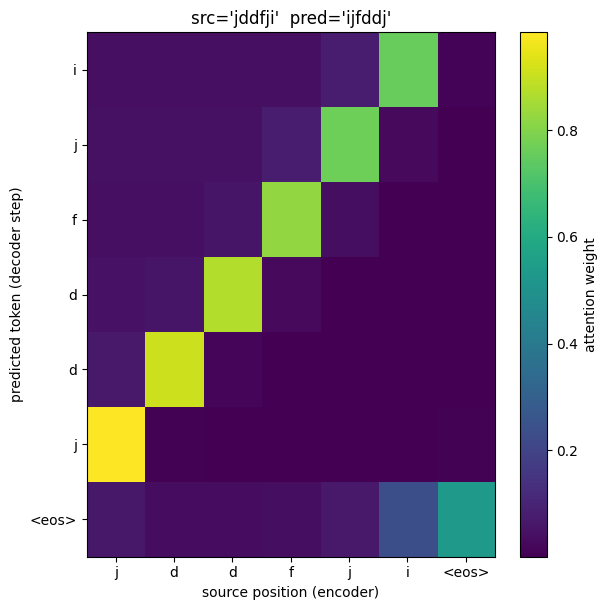

In [14]:
def plot_attention(src_ids, pred_ids, attn_weights, title="Attention weights"):
    """
    src_ids:      list/tensor of source token ids (including <eos>, excluding padding)
    pred_ids:     list/tensor of predicted token ids (including <eos>)
    attn_weights: (pred_len, src_len) tensor/array of attention weights
    """
    src_len_real = len(src_ids)
    pred_len_real = len(pred_ids)
    attn = attn_weights[:pred_len_real, :src_len_real]

    src_labels  = [idx2token[int(i)] for i in src_ids]
    pred_labels = [idx2token[int(i)] for i in pred_ids]

    fig, ax = plt.subplots(figsize=(0.6*src_len_real + 2, 0.6*pred_len_real + 2))
    im = ax.imshow(attn, cmap="viridis", aspect="auto")
    ax.set_xticks(range(src_len_real))
    ax.set_xticklabels(src_labels)
    ax.set_yticks(range(pred_len_real))
    ax.set_yticklabels(pred_labels)
    ax.set_xlabel("source position (encoder)")
    ax.set_ylabel("predicted token (decoder step)")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label="attention weight")
    plt.tight_layout()
    plt.show()


# pick one example from the batch and find where <eos> falls for clean trimming
example_idx = 0
src_ids_full = src[example_idx].tolist()
pred_ids_full = pred_tokens[example_idx].tolist()

src_real_len = src_ids_full.index(EOS) + 1 if EOS in src_ids_full else len(src_ids_full)
pred_real_len = pred_ids_full.index(EOS) + 1 if EOS in pred_ids_full else len(pred_ids_full)

src_ids_trim  = src_ids_full[:src_real_len]
pred_ids_trim = pred_ids_full[:pred_real_len]
attn_trim = attn[example_idx].detach().cpu().numpy()

plot_attention(src_ids_trim, pred_ids_trim, attn_trim,
               title=f"src='{tokens_to_str(src_ids_full)}'  pred='{tokens_to_str(pred_ids_full)}'")

If training went well, you should see a bright band running from the **top-right toward the bottom-left** — the first predicted token attending to the *last* real source token, the second predicted token attending to the second-to-last, and so on. That anti-diagonal is the model having learned, purely from data, exactly the alignment a reversal task requires — with no explicit supervision on *what* to attend to, only on the final output sequence.

## 12. Summary & where to go next

**What we built:**
- A bidirectional GRU encoder that keeps *all* per-token hidden states around (not just a single summary vector)
- Bahdanau additive attention: $score = v^\top\tanh(W_s s + W_h h_i)$, softmax-normalized into weights, used to compute a context vector that's recomputed at every decoder step
- A GRU decoder that conditions on `[input embedding ; attention context]`, with a "deep output" layer that also sees the context and embedding directly
- Teacher forcing with linear decay, masked cross-entropy loss, gradient clipping
- Attention-weight visualization to sanity-check the learned alignment

**Extending this to a real translation task:**
- Swap `ReverseDataset`/`make_example` for a real parallel corpus loader (e.g. tokenized sentence pairs from a dataset like Multi30k or a TSV of sentence pairs), with separate source/target vocabularies built via a tokenizer of your choice
- Increase `EMB_DIM`/`ENC_HIDDEN`/`DEC_HIDDEN`, add more GRU/LSTM layers, and consider beam search instead of greedy decoding for better output quality
- Add subword tokenization (e.g. BPE) so the vocabulary generalizes beyond a fixed token set
- For longer sequences, this same attention mechanism is exactly what motivated the Transformer's self-attention — once you're comfortable with this notebook, reading the original Transformer paper's attention section should feel very familiar